---
date: "2026-08-10"
date-modified: last-modified
format:
  html:
    toc: true
---



# Risk Measures

Risk measurement is a foundational concept in mathematical finance, decision theory, and portfolio management. To quantify the uncertainty associated with financial investments, mathematical models establish formal mappings from [random variables](random-variables.ipynb) to scalar risk measures.

## 1\. Variance as a Risk Measure

In classic modern portfolio theory, the canonical metric for asset risk is **variance** (or its square root, **standard deviation**). While the [Expected Value](expectation.ipynb) $\mu = \mathbb{E}[R]$ locates the central expectation of an asset's return distribution, variance quantifies the dispersion of actual returns around that center.

::: {#def-variance-risk}
## Definition: Variance of Return
Let $R$ be a real-valued [random variable](random-variables.ipynb) representing the net return of a financial asset over a given holding period, with finite expected return $\mu = \mathbb{E}[R] < \infty$.

The **variance of return**, denoted $\text{Var}(R)$ or $\sigma^2$, is defined as the expected squared deviation from the mean:

$$
\text{Var}(R) = \mathbb{E}\left[(R - \mu)^2\right]
$$

The **standard deviation** $\sigma = \sqrt{\text{Var}(R)}$ measures return volatility in the same physical units (percentage or monetary currency) as the return $R$.
:::

::: {#prp-variance-computational}
## Proposition: Alternate Computational Formula
For any return random variable $R$ with finite second moment $\mathbb{E}[R^2] < \infty$, the variance satisfies:

$$
\text{Var}(R) = \mathbb{E}[R^2] - \mu^2 = \mathbb{E}[R^2] - (\mathbb{E}[R])^2
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Computational Variance Formula
Let $\mu = \mathbb{E}[R]$. Note that $\mu$ is a deterministic scalar constant.

$$
\begin{aligned}
\text{Var}(R) &= \mathbb{E}\left[(R - \mu)^2\right] \\
&= \mathbb{E}\left[R^2 - 2\mu R + \mu^2\right] \\
&= \mathbb{E}[R^2] - \mathbb{E}[2\mu R] + \mathbb{E}[\mu^2] \quad \text{(by [Linearity of Expectation](expectation.ipynb))} \\
&= \mathbb{E}[R^2] - 2\mu \mathbb{E}[R] + \mu^2 \\
&= \mathbb{E}[R^2] - 2\mu(\mu) + \mu^2 \\
&= \mathbb{E}[R^2] - 2\mu^2 + \mu^2 \\
&= \mathbb{E}[R^2] - \mu^2 = \mathbb{E}[R^2] - (\mathbb{E}[R])^2 \quad \blacksquare
\end{aligned}
$$
:::

::: {.callout-note}
## Intuition: Dispersion Around the Center
Variance measures how widely an asset's returns fluctuate relative to their expected value. Higher variance implies greater uncertainty regarding the realized outcome at the end of the investment period.
:::



## 2\. Financial Leverage and Leveraged Return Dynamics

Financial **leverage** involves using borrowed debt capital alongside equity capital to fund an asset position. This structural weighting amplifies both expected return and risk exposure.

### 2.1\. Leveraged Return Model

Consider a single-period horizon $T = \{0, 1\}$ within the [Single-Period Investment Model](single-period-investment-model.ipynb).

Let:

- $S_0 > 0$ be the deterministic asset price at time $T=0$.
- $S_1$ be the random asset price at time $T=1$.
- $R_s = \frac{S_1 - S_0}{S_0}$ be the unleveraged net asset return, with mean $\mu_s = \mathbb{E}[R_s]$ and variance $\sigma_s^2 = \text{Var}(R_s)$.
- $R_{rf}$ be the deterministic risk-free interest rate.

Suppose an investor purchases 1 share of asset (costing $S_0$) at $T=0$, but funds it using an equity fraction $w \in (0, 1]$ ($E_0 = w S_0$) and borrows debt fraction $(1-w) S_0$ at the risk-free rate $R_{rf}$.

At $T=0$, total capital invested is $E_0 + D_0 = w S_0 + (1-w) S_0 = S_0$.

At $T=1$:

- Asset terminal value is $S_1$.
- Debt repayment obligation (principal + interest) is $(1 + R_{rf})(1-w) S_0$.
- Terminal equity value is $E_1 = S_1 - (1 + R_{rf})(1-w) S_0$.

::: {#def-leveraged-return}
## Definition: Leveraged Net Return on Equity
The **leveraged net return** $R_{\text{lev}}$ is the rate of return realized relative to initial equity capital $E_0 = w S_0$:

$$
R_{\text{lev}} = \frac{E_1 - E_0}{E_0} = \frac{S_1 - (1 + R_{rf})(1-w) S_0 - w S_0}{w S_0}
$$
:::

::: {#thm-leverage-risk-scaling}
## Theorem: Leverage Return Decomposition and Risk Scaling
For equity weight $w \in (0, 1]$, the leveraged net return satisfies:

$$
R_{\text{lev}} = \frac{1}{w}(R_s - R_{rf}) + R_{rf}
$$

The expected return and standard deviation scale linearly with the leverage multiplier $\frac{1}{w}$:

$$
\mathbb{E}[R_{\text{lev}}] = \frac{1}{w}(\mu_s - R_{rf}) + R_{rf}
$$

$$
\text{Var}(R_{\text{lev}}) = \frac{1}{w^2} \text{Var}(R_s) \implies \sigma_{\text{lev}} = \frac{1}{w} \sigma_s
$$
:::

::: {.callout-tip collapse="true"}
## Derivation of Leveraged Return Dynamics and Scaling
Starting from the definition of $R_{\text{lev}}$:

$$
\begin{aligned}
R_{\text{lev}} &= \frac{S_1 - (1 + R_{rf})(1-w)S_0 - w S_0}{w S_0} \\
&= \frac{S_1 - S_0\Big((1-w) + R_{rf}(1-w) + w\Big)}{w S_0} \\
&= \frac{S_1 - S_0\Big(1 + R_{rf}(1-w)\Big)}{w S_0} \\
&= \frac{(S_1 - S_0) - R_{rf}(1-w)S_0}{w S_0} \\
&= \frac{\frac{S_1 - S_0}{S_0} - R_{rf}(1-w)}{w} \\
&= \frac{R_s - R_{rf} + w R_{rf}}{w} \\
&= \frac{1}{w}(R_s - R_{rf}) + R_{rf}
\end{aligned}
$$

Taking expectations using linearity:

$$
\begin{aligned}
\mathbb{E}[R_{\text{lev}}] &= \mathbb{E}\left[\frac{1}{w}(R_s - R_{rf}) + R_{rf}\right] \\
&= \frac{1}{w}\Big(\mathbb{E}[R_s] - R_{rf}\Big) + R_{rf} \quad \text{(since } R_{rf}, w \text{ are deterministic)} \\
&= \frac{1}{w}(\mu_s - R_{rf}) + R_{rf}
\end{aligned}
$$

Taking variance:

$$
\begin{aligned}
\text{Var}(R_{\text{lev}}) &= \text{Var}\left(\frac{1}{w} R_s + R_{rf}\left(1 - \frac{1}{w}\right)\right) \\
&= \left(\frac{1}{w}\right)^2 \text{Var}(R_s) \quad \text{(as deterministic shifts leave variance unchanged)} \\
&= \frac{1}{w^2} \sigma_s^2
\end{aligned}
$$

Taking the positive square root yields the risk scaling formula:

$$
\sigma_{\text{lev}} = \frac{1}{w} \sigma_s \quad \blacksquare
$$
:::

::: {.callout-note}
## Intuition: Financial Leverage as a Seesaw
Financial leverage functions like a mechanical lever whose fulcrum position is governed by equity weight $w$:

- **Unleveraged ($w = 1.0$):** $R_{\text{lev}} = 1 \times (R_s - R_{rf}) + R_{rf} = R_s$, so risk is $\sigma_{\text{lev}} = \sigma_s$.
- **$10\times$ Leverage ($w = 0.10$ / $10\%$ margin):** $R_{\text{lev}} = 10(R_s - R_{rf}) + R_{rf}$, scaling risk to $\sigma_{\text{lev}} = 10\sigma_s$.
- **$100\times$ Leverage ($w = 0.01$ / $1\%$ margin):** $R_{\text{lev}} = 100(R_s - R_{rf}) + R_{rf}$, scaling risk to $\sigma_{\text{lev}} = 100\sigma_s$.

As equity margin $w \to 0$, return variance and risk explode proportionally to $1/w^2$ and $1/w$.
:::


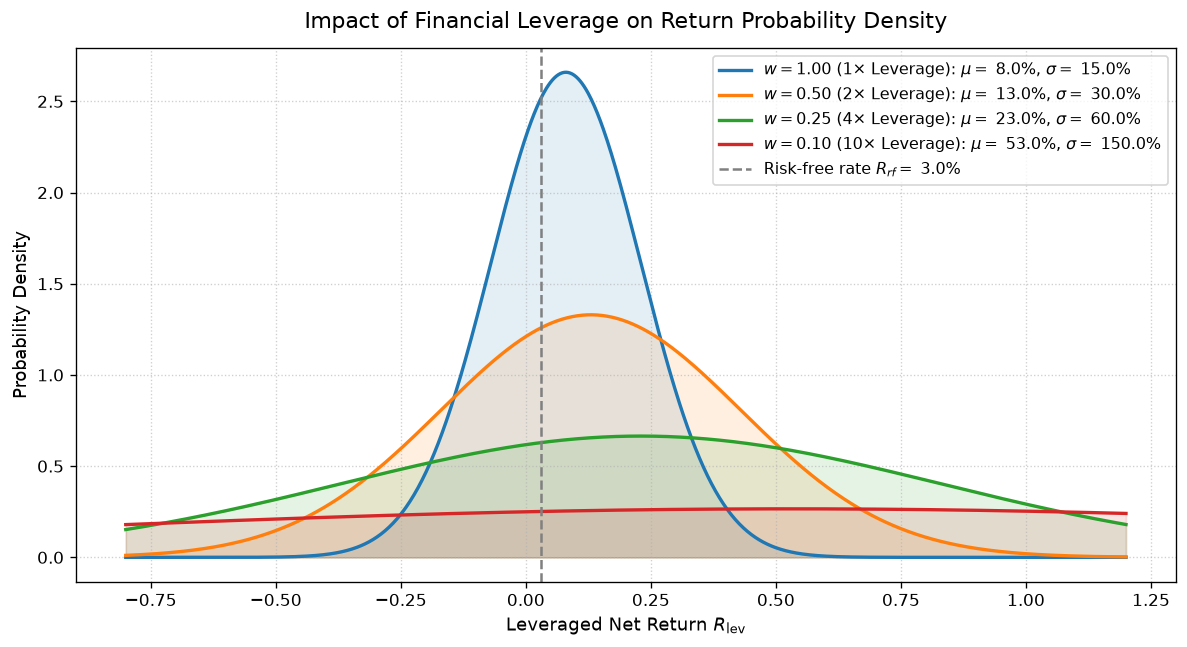

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set random seed for reproducibility
np.random.seed(42)

# Unleveraged asset parameters
mu_s = 0.08      # 8% expected stock return
sigma_s = 0.15   # 15% annual volatility
R_rf = 0.03      # 3% risk-free rate

# Leverage weights w (equity fraction)
weights = [1.0, 0.5, 0.25, 0.10]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

r_range = np.linspace(-0.8, 1.2, 1000)

plt.figure(figsize=(10, 5.5), dpi=120)

for w, color in zip(weights, colors):
    mu_lev = (1 / w) * (mu_s - R_rf) + R_rf
    sigma_lev = (1 / w) * sigma_s
    pdf = stats.norm.pdf(r_range, loc=mu_lev, scale=sigma_lev)
    
    # Placed formatted percentage strings outside of math mode ($...$)
    label = f"$w = {w:.2f}$ ({1/w:.0f}$\\times$ Leverage): $\\mu =$ {mu_lev:.1%}, $\\sigma =$ {sigma_lev:.1%}"
    plt.plot(r_range, pdf, label=label, color=color, linewidth=2)
    plt.fill_between(r_range, 0, pdf, color=color, alpha=0.12)

plt.axvline(R_rf, color='gray', linestyle='--', label=f"Risk-free rate $R_{{rf}} =$ {R_rf:.1%}")
plt.title("Impact of Financial Leverage on Return Probability Density", fontsize=13, pad=12)
plt.xlabel("Leveraged Net Return $R_{\\text{lev}}$", fontsize=11)
plt.ylabel("Probability Density", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9.5, loc="upper right")
plt.tight_layout()
plt.show()

## 3\. Mean-Variance Dominance and the Efficient Set

In modern portfolio theory, investments are mapped into risk-return space $(\sigma, \mu)$. Rational investors evaluate potential opportunities through the principle of **dominance**.

::: {#def-mean-variance-dominance}
## Definition: Mean-Variance Dominance
Let asset $i$ have expected return $\mu_i$ and risk $\sigma_i$, and asset $j$ have expected return $\mu_j$ and risk $\sigma_j$.

Asset $j$ **dominates** asset $i$ (denoted $j \succ i$) if and only if:

$$
\mu_j \ge \mu_i \quad \text{and} \quad \sigma_j \le \sigma_i
$$

with at least one strict inequality ($\mu_j > \mu_i$ or $\sigma_j < \sigma_i$).
:::

::: {#def-efficient-set}
## Definition: Efficient Set (Efficient Frontier)
Given a collection of available assets or portfolios $\mathcal{P}$, the **Efficient Set** (or **Efficient Frontier**) $\mathcal{E} \subseteq \mathcal{P}$ consists of all assets that are **not dominated** by any other asset in $\mathcal{P}$:

$$
\mathcal{E} = \{ i \in \mathcal{P} \mid \nexists j \in \mathcal{P} \text{ such that } j \succ i \}
$$
:::

::: {.callout-note}
## Intuition: Rational Selection Boundary
A risk-averse investor will never hold a dominated asset when an alternative asset offers higher expected return for equal/lower risk (or lower risk for equal/higher return). In $(\sigma, \mu)$ space, the Efficient Set traces out the upper-left boundary of non-dominated investment choices.
:::


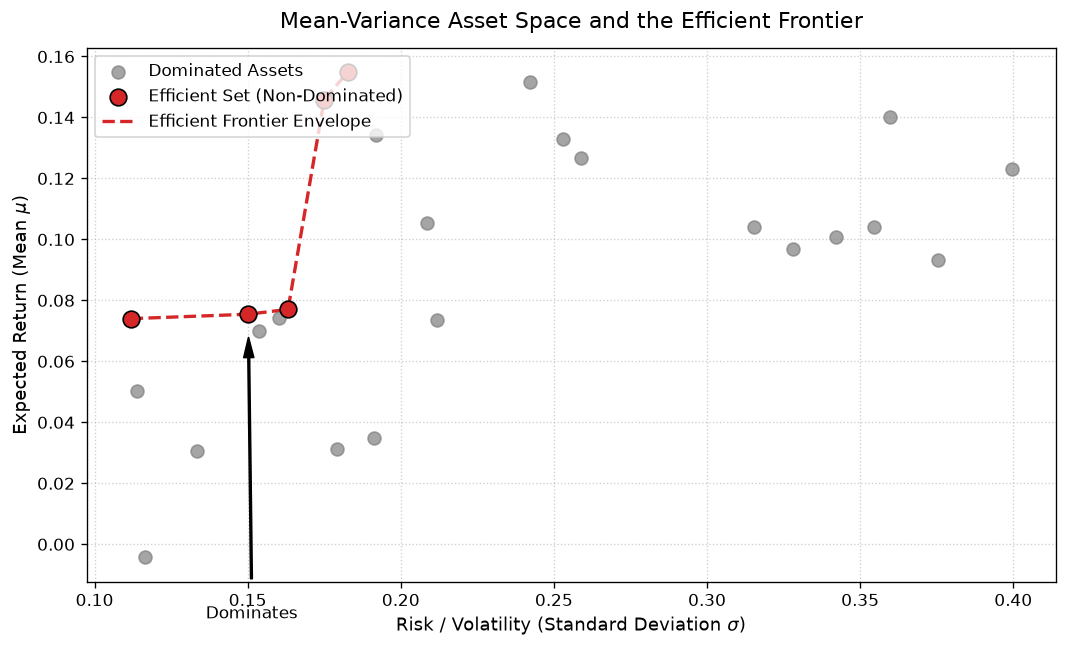

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate stock opportunity set
np.random.seed(15)
n_stocks = 25
sigmas = np.random.uniform(0.10, 0.40, n_stocks)
mus = 0.02 + 0.35 * sigmas + np.random.normal(0, 0.035, n_stocks)

# Identify non-dominated stocks (Efficient Set)
is_efficient = np.ones(n_stocks, dtype=bool)
for i in range(n_stocks):
    for j in range(n_stocks):
        if i != j:
            if (mus[j] >= mus[i] and sigmas[j] <= sigmas[i]) and (mus[j] > mus[i] or sigmas[j] < sigmas[i]):
                is_efficient[i] = False
                break

plt.figure(figsize=(9, 5.5), dpi=120)

# Plot inefficient stocks
plt.scatter(sigmas[~is_efficient], mus[~is_efficient], color='#7f7f7f', s=60, alpha=0.7, label="Dominated Assets", zorder=3)

# Plot efficient set
efficient_indices = np.where(is_efficient)[0]
sorted_eff = sorted(efficient_indices, key=lambda idx: sigmas[idx])
eff_sigmas = sigmas[sorted_eff]
eff_mus = mus[sorted_eff]

plt.scatter(eff_sigmas, eff_mus, color='#d62728', s=100, edgecolors='black', label="Efficient Set (Non-Dominated)", zorder=4)
plt.plot(eff_sigmas, eff_mus, color='#d62728', linestyle='--', linewidth=2, label="Efficient Frontier Envelope", zorder=3)

# Annotate dominance relationship
dom_idx = np.where(~is_efficient)[0][2]
better_idx = sorted_eff[1]
plt.annotate("Dominates", xy=(sigmas[better_idx], mus[better_idx]), xytext=(sigmas[dom_idx]+0.02, mus[dom_idx]-0.02),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6), fontsize=10)

plt.title("Mean-Variance Asset Space and the Efficient Frontier", fontsize=13, pad=12)
plt.xlabel(r"Risk / Volatility (Standard Deviation $\sigma$)", fontsize=11)
plt.ylabel(r"Expected Return (Mean $\mu$)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()


## 4\. Limitations of Variance & Semivariance (Downside Risk)

::: {.callout-warning}
## Warning: The Symmetry Caveat of Variance
Variance measures squared deviations $(R - \mu)^2$ symmetrically around the mean. Consequently, variance treats positive windfalls ($R \gg \mu$) as equally risky as catastrophic losses ($R \ll \mu$).
:::

In real-world investment applications, upside volatility represents desirable opportunity, whereas downside volatility represents capital loss. To measure true loss vulnerability, Harry Markowitz introduced **semivariance**.

::: {#def-semivariance}
## Definition: Semivariance (Downside Risk)
Let $R$ be a return random variable with mean $\mu = \mathbb{E}[R]$. The **semivariance** $\sigma_{\text{semi}}^2$ relative to mean $\mu$ (or a benchmark return target $B$) is defined as:

$$
\sigma_{\text{semi}}^2 = \mathbb{E}\left[ \left( \min(0, R - \mu) \right)^2 \right]
$$

More generally, relative to a target benchmark $B \in \mathbb{R}$:

$$
\sigma_{\text{semi}}^2(B) = \mathbb{E}\left[ \left( \min(0, R - B) \right)^2 \right] = \int_{-\infty}^{B} (r - B)^2 f_R(r) \, dr
$$

where $f_R(r)$ is the [Probability Density Function](probability-density-function.ipynb) of $R$.
:::

::: {.callout-note}
## Intuition: Downside vs. Full Variance
- For symmetric return distributions (such as the [Normal Distribution](normal-distribution.ipynb)), semivariance equals exactly half of total variance: $\sigma_{\text{semi}}^2 = \frac{1}{2}\sigma^2$.
- For positively skewed distributions (e.g. options payouts or venture investments with long right tails), total variance overstates risk by penalizing upside profits. Semivariance sets $(R - \mu) = 0$ whenever $R \ge \mu$, focusing exclusively on downside capital preservation.
:::


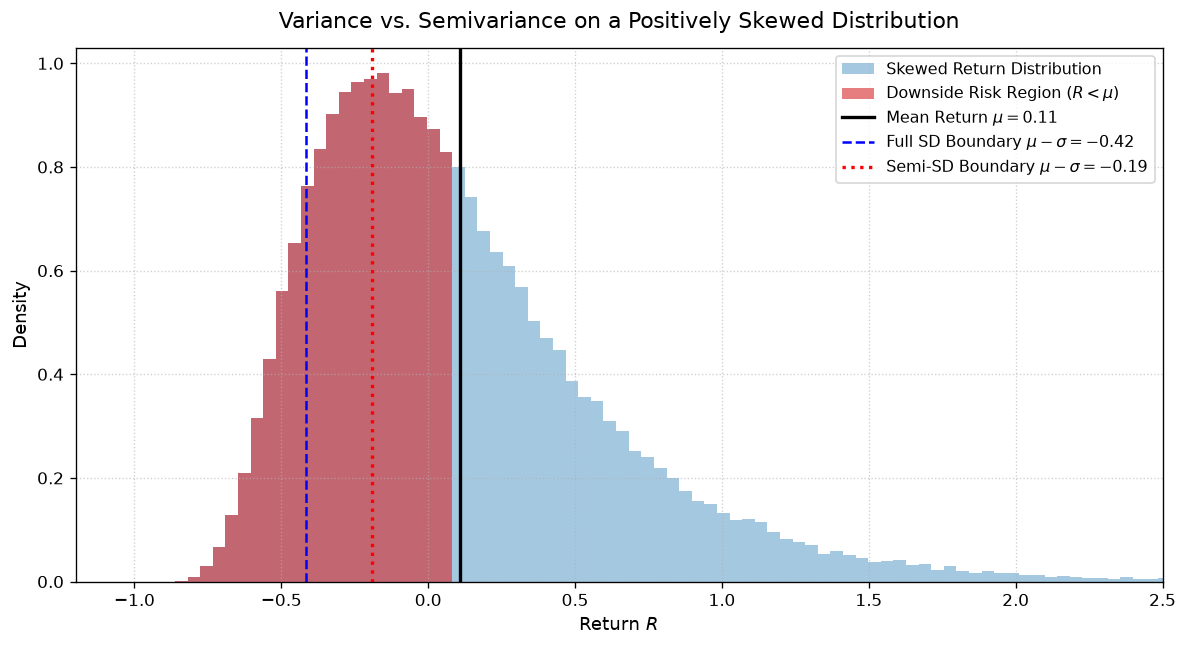

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate a right-skewed return distribution
np.random.seed(123)
returns = np.random.lognormal(mean=0.0, sigma=0.45, size=100000) - 1.0

mu = np.mean(returns)
variance = np.var(returns)
std_dev = np.sqrt(variance)

# Compute Semivariance below mean mu
downside_diffs = np.minimum(0, returns - mu)
semivariance = np.mean(downside_diffs**2)
semi_std_dev = np.sqrt(semivariance)

plt.figure(figsize=(10, 5.5), dpi=120)

# Full distribution plot
count, bins, _ = plt.hist(returns, bins=150, density=True, alpha=0.4, color='#1f77b4', label="Skewed Return Distribution")

# Highlight downside region - correctly weighted so bar heights match the main density plot
downside_returns = returns[returns < mu]
bin_width = bins[1] - bins[0]
weights = np.ones_like(downside_returns) / (len(returns) * bin_width)

plt.hist(downside_returns, bins=bins[bins <= mu], weights=weights, alpha=0.6, color='#d62728', label=r"Downside Risk Region ($R < \mu$)")

# Vertical reference lines using raw f-strings (rf"...") to prevent LaTeX escape warnings
plt.axvline(mu, color='black', linestyle='-', linewidth=2, label=rf"Mean Return $\mu = {mu:.2f}$")
plt.axvline(mu - std_dev, color='blue', linestyle='--', label=rf"Full SD Boundary $\mu - \sigma = {mu - std_dev:.2f}$")
plt.axvline(mu - semi_std_dev, color='red', linestyle=':', linewidth=2, label=rf"Semi-SD Boundary $\mu - \sigma={mu - semi_std_dev:.2f}$")

plt.title("Variance vs. Semivariance on a Positively Skewed Distribution", fontsize=13, pad=12)
plt.xlabel("Return $R$", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.xlim(-1.2, 2.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9.5, loc="upper right")
plt.tight_layout()
plt.show()